# CIFAR 10 Classification

## 1.1 Training and testing a Deep neural network model in pytorch similar to pytorch documentation with gpu acceleration

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

In [2]:
# Define transformations for the training and testing data
# The images are converted to tensors and normalized to have a mean of 0.5 and a standard deviation of 0.5 for each color channel.
# to make the pixel values range from -1 to 1, and center at 0 this can help with convergence.
transform = transforms.Compose(
    [
        # converting the images to PyTorch tensors and normalize them
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

batch_size = 4

# loading train set and using train loader to iterate through the dataset in batches of 4
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=False, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

# same here but for test set
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=False, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# defining the classes in the CIFAR-10 dataset
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

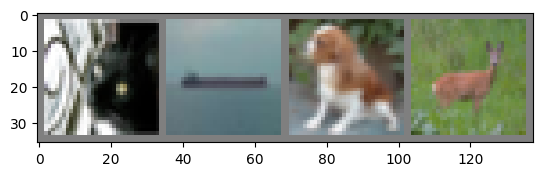

class: cat class: ship class: dog class: deer


In [3]:
import matplotlib.pyplot as plt

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(npimg.transpose((1, 2, 0)))
    plt.show()

# Get some random training images
# the iter() function is used to create an iterator from the trainloader,
# and the next() function is called to retrieve the next batch of images and labels from the iterator.
# so for this instance we will just retrieve the first batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))

print(' '.join(f'class: {classes[labels[j]]}' for j in range(batch_size)))

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class Net (nn.Module):
    def __init__(self):
        # the super() function is used to call the __init__ method of the parent class (nn.Module) to ensure that the base class is properly initialized.
        super(Net, self).__init__()
        # first convolutional layer takes 3 input channels (RGB) and produces 6 output(features) channels using a kernel size of 5
        # the output image size will be ((input_size - kernel_size + 2 * padding) / stride) + 1 which will be ((32 - 5 + 0) / 1) + 1 = 28
        self.conv1 = nn.Conv2d(3, 6, 5)
        # the max pooling layer is defined with a kernel size of 2 and a stride of 2, which will downsample the feature maps by a factor of 2.
        # in this case 28 will downsampled to 14
        self.pool= nn.MaxPool2d(2,2)
        # the second convolutional layer takes 6 input channels (from the previous layer) and produces 16 output channels using a kernel size of 5.
        # the output image size will be ((14 - 5 + 0) / 1) + 1 = 10
        self.conv2 = nn.Conv2d(6, 16, 5)
        # the fully connected layers are defined to take the output from the convolutional layers and produce the final class scores.
        # since in the forward method we will run the second convolutional layer through another max pooling layer the output image size will be downsampled to 5
        # so the input to the first fully connected layer will be 16 * 5 * 5 = 400 features which is 16 output channels * 5 height * 5 width
        # the 120 output features are arbitrary and can be adjusted based on the desired model complexity and performance.
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # the second fully connected layer takes 120 input features which is the output from the first fully connected layer and produces 84 output features.
        # the 84 output features are also arbitrary and can be adjusted based on the desired model complexity and performance.
        self.fc2 = nn.Linear(120, 84)
        # the final fully connected layer takes 84 input features which is the output from the second fully connected layer and produces 10 output features
        # the 10 output features correspond to the 10 classes in the CIFAR-10 dataset, and will represent the predicted class scores for each input image.
        # we need the outputs to be logits (raw scores) because we will apply the CrossEntropyLoss which combines the softmax activation function
        # and the negative log-likelihood loss in one single class.
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        # the forward method defines how the input data flows through the network layers to produce the output.
        # the input x is passed through the first convolutional layer, followed by a ReLU activation function and a max pooling layer.
        x = self.pool(F.relu(self.conv1(x)))
        # same here
        x = self.pool(F.relu(self.conv2(x)))
        # the output of the final pooling layer is then flattened into a 1D vector to be fed into the fully connected layers.
        x = torch.flatten(x, 1)
        # the flattened output is passed througha relu activation function after each fully connected layer
        x = F.relu(self.fc1(x))
        # the output of the first fully connected layer is passed through the second fully connected layer, followed by a ReLU activation function.
        x = F.relu(self.fc2(x))
        # the final output is produced by passing the output of the second fully connected layer through the third fully connected layer,
        # which produces the class scores (logits) for each input image.
        x = self.fc3(x)
        return x
    
net = Net()

In [5]:
import torch.optim as optim

# the CrossEntropyLoss is used as the loss function for training the network, which is suitable for multi-class classification problems like CIFAR-10.
criterion = nn.CrossEntropyLoss()
# the Stochastic Gradient Descent (SGD) optimizer is used to update the model's parameters during training, with a learning rate of 0.001 and a momentum of 0.9\
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [6]:
start = time.perf_counter()
for epoch in range(10):
    # the running_loss variable is initialized to 0.0 
    # at the beginning of each epoch to keep track of the cumulative loss during training.
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # splitting the data into inputs and labels,
        # where inputs are the images and labels are the corresponding class labels for those images.
        inputs, labels = data
        
        # zero the parameter gradients to prevent accumulation from previous iterations
        optimizer.zero_grad()
        # forward pass through the network to get outputs
        outputs = net(inputs)
        # compute the loss between the predicted outputs and the true labels using cross-entropy loss
        loss = criterion(outputs, labels)
        # using pytorch auto grad to backpropagate and compute the gradients of the loss 
        # with respect to the model parameters
        loss.backward()
        # update the model parameters using the optimizer based on the computed gradients
        optimizer.step()
        
        # accumulate the loss for reporting purposes
        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

end = time.perf_counter()
time_cpu = end - start      
print(f'Finished Training in {time_cpu:.2f} seconds')



[1,  2000] loss: 2.185
[1,  4000] loss: 1.842
[1,  6000] loss: 1.669
[1,  8000] loss: 1.557
[1, 10000] loss: 1.503
[1, 12000] loss: 1.471
[2,  2000] loss: 1.404
[2,  4000] loss: 1.384
[2,  6000] loss: 1.350
[2,  8000] loss: 1.329
[2, 10000] loss: 1.324
[2, 12000] loss: 1.265
[3,  2000] loss: 1.213
[3,  4000] loss: 1.213
[3,  6000] loss: 1.219
[3,  8000] loss: 1.199
[3, 10000] loss: 1.196
[3, 12000] loss: 1.175
[4,  2000] loss: 1.113
[4,  4000] loss: 1.102
[4,  6000] loss: 1.111
[4,  8000] loss: 1.128
[4, 10000] loss: 1.109
[4, 12000] loss: 1.120
[5,  2000] loss: 1.015
[5,  4000] loss: 1.049
[5,  6000] loss: 1.058
[5,  8000] loss: 1.018
[5, 10000] loss: 1.063
[5, 12000] loss: 1.045
[6,  2000] loss: 0.950
[6,  4000] loss: 0.969
[6,  6000] loss: 0.987
[6,  8000] loss: 0.995
[6, 10000] loss: 1.003
[6, 12000] loss: 1.005
[7,  2000] loss: 0.912
[7,  4000] loss: 0.929
[7,  6000] loss: 0.925
[7,  8000] loss: 0.967
[7, 10000] loss: 0.945
[7, 12000] loss: 0.961
[8,  2000] loss: 0.883
[8,  4000] 

In [ ]:
#Saving the trained model's state dictionary to a file named 'cifar_net_cpu_baseline.pth' using torch.save() function.
#net.state_dict() returns a dictionary containing the model's parameters (weights and biases) and their corresponding values.
Path = './models/cifar_net_cpu_baseline.pth'
torch.save(net.state_dict(), Path)

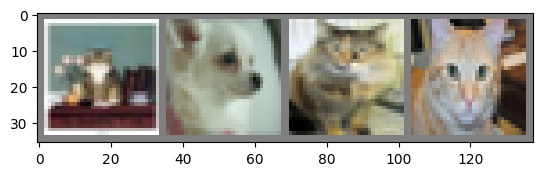

Labels:  cat dog cat cat


In [8]:
# visualize some of the test images along with their corresponding labels
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('Labels: ', ' '.join(f'{classes[labels[j]]}' for j in range(batch_size)))

In [9]:
# the trained model is used to make predictions on the images above by passing them through the network to obtain the logits
outputs = net(images)

# the torch.max() function is used to find the maximum value along a specified dimension of the output tensor 
# in this case the dimension is 1 which corresponds to the class scores for each input image,
# which corresponds to the predicted class with the highest logit.
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  truck cat   cat   cat  


In [10]:
correct = 0
total = 0

# the with torch.no_grad() context is used to disable gradient calculation during the evaluation phase,
# which can save memory and computational resources since we are not updating the model parameters.
with torch.no_grad():
    for data in testloader:
        # we are iterating through the testloader to get batches of test data, and for each batch we are splitting it into inputs and labels.
        # then we are passing the inputs through the trained network to get predictions then getting the max predicted class
        # as we did before
        inputs, labels = data
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        # getting total input size are passing 0  in .size() because 0 corresponds to the batch dimension
        # and we want to sum over all the samples in the batch
        total += labels.size(0)
        # getting correct predictions
        correct += (predicted == labels).sum().item()

accuracy_cpu = 100 * correct / total

print(f'Accuracy of the network on the 10000 test images: {accuracy_cpu}%')

Accuracy of the network on the 10000 test images: 61.46%


In [11]:
# to calculate the accuracy for each class in the CIFAR-10 dataset, we initialize two dictionaries: correct_predict and total_predict.
# we iterate through classes and set the initial count of correct predictions and total predictions for each class to 0.
correct_predict = {classname: 0 for classname in classes}
total_predict = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        # same as before
        inputs, labels = data
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)
        # we iterate through the predicted and true labels for each sample in the batch using zip() function,
        # and we check if the predicted label matches the true label.
        # zip() function is used to pair each true label with its corresponding predicted label
        # ex: if we have labels = [0, 1, 2] and predicted = [0, 2, 2], zip(labels, predicted) will produce pairs (0, 0), (1, 2), and (2, 2).
        for label, prediction in zip(labels, predicted):
            # if the predicted label matches the true label, we increment the count of correct predictions for that class in the correct_predict dictionary.
            if label == prediction:
                correct_predict[classes[label]] += 1
            # in all casses we increment the total count of predictions for that class in the total_predict dictionary.
            total_predict[classes[label]] += 1

# we iterate through each class in the correct_predict dictionary, calculate the accuracy for that class by dividing
accuracy_per_class_cpu = {}
for classname, correct_count in correct_predict.items():
    # accuracy = 100 * correct / total to get the percentage of correct predictions for that class\
    accuracy = 100 * correct_count / total_predict[classname]
    accuracy_per_class_cpu[classname] = accuracy
    print(f'Accuracy for class {classname:5s} is {accuracy:.1f} %')

Accuracy for class plane is 71.3 %
Accuracy for class car   is 77.5 %
Accuracy for class bird  is 52.1 %
Accuracy for class cat   is 56.1 %
Accuracy for class deer  is 52.7 %
Accuracy for class dog   is 35.8 %
Accuracy for class frog  is 66.8 %
Accuracy for class horse is 70.9 %
Accuracy for class ship  is 65.9 %
Accuracy for class truck is 65.5 %


## GPU Training

In [12]:
# checking if CUDA is available and set the device accordingly,
# if a GPU is available it will use it for computations, otherwise it will fall back to using the CPU.
# in this case I am using RTX 3060 GPU which has CUDA support
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

net_gpu = Net()

# switchng the model to use GPU
net_gpu.to(device)

cuda:0


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [13]:
optimizer_gpu = optim.SGD(net_gpu.parameters(), lr=0.001, momentum=0.9)

In [14]:
start = time.perf_counter()
# reusing the same training loop as before but now with the model
# and data on the GPU to take advantage of faster computations.
for epoch in range(10):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        
        # moving the inputs and labels to the same device as the model (GPU in this case)
        # to ensure that the computations are performed on the GPU.
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer_gpu.zero_grad()
        
        outputs = net_gpu(inputs)
        
        loss = criterion(outputs, labels)

        loss.backward()
    
        optimizer_gpu.step()
        
        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

end = time.perf_counter()
time_gpu = end - start      
print(f'Finished Training in {time_gpu:.2f} seconds')

[1,  2000] loss: 2.213
[1,  4000] loss: 1.858
[1,  6000] loss: 1.658
[1,  8000] loss: 1.574
[1, 10000] loss: 1.498
[1, 12000] loss: 1.443
[2,  2000] loss: 1.392
[2,  4000] loss: 1.355
[2,  6000] loss: 1.331
[2,  8000] loss: 1.313
[2, 10000] loss: 1.295
[2, 12000] loss: 1.258
[3,  2000] loss: 1.201
[3,  4000] loss: 1.204
[3,  6000] loss: 1.185
[3,  8000] loss: 1.188
[3, 10000] loss: 1.151
[3, 12000] loss: 1.139
[4,  2000] loss: 1.066
[4,  4000] loss: 1.100
[4,  6000] loss: 1.080
[4,  8000] loss: 1.093
[4, 10000] loss: 1.083
[4, 12000] loss: 1.089
[5,  2000] loss: 1.007
[5,  4000] loss: 1.024
[5,  6000] loss: 1.012
[5,  8000] loss: 1.029
[5, 10000] loss: 1.028
[5, 12000] loss: 1.025
[6,  2000] loss: 0.958
[6,  4000] loss: 0.950
[6,  6000] loss: 0.944
[6,  8000] loss: 0.973
[6, 10000] loss: 0.971
[6, 12000] loss: 0.967
[7,  2000] loss: 0.894
[7,  4000] loss: 0.933
[7,  6000] loss: 0.928
[7,  8000] loss: 0.918
[7, 10000] loss: 0.930
[7, 12000] loss: 0.947
[8,  2000] loss: 0.844
[8,  4000] 

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1856\2157155883.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['CPU', 'GPU'], y=[time_cpu, time_gpu], palette='viridis')


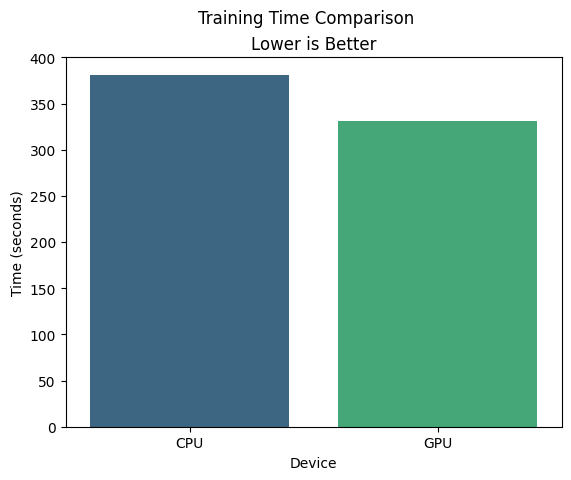

In [ ]:
import seaborn as sns

# Creating a bar plot to compare the training times
sns.barplot(x=['CPU', 'GPU'], y=[time_cpu, time_gpu], palette='viridis')
plt.suptitle('Training Time Comparison')
plt.title('Lower is Better')
plt.xlabel('Device')
plt.ylabel('Time (seconds)')

plt.show()

### gpu training time is significantly lower than cpu training time which shows how parallel computations on the GPU can speed up the training process for deep learning models

In [16]:
correct = 0
total = 0

# similar to before we are evaluating the model's performance on the test set,
# but now we are using the model that was trained on the GPU.
with torch.no_grad():
    for data in testloader:
        inputs, labels = data
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = net_gpu(inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy_gpu = 100 * correct / total

print(f'Accuracy of the network on the 10000 test images: {accuracy_gpu}%')

Accuracy of the network on the 10000 test images: 62.88%


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1856\2102174271.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['CPU', 'GPU'], y=[accuracy_cpu, accuracy_gpu], palette='viridis')


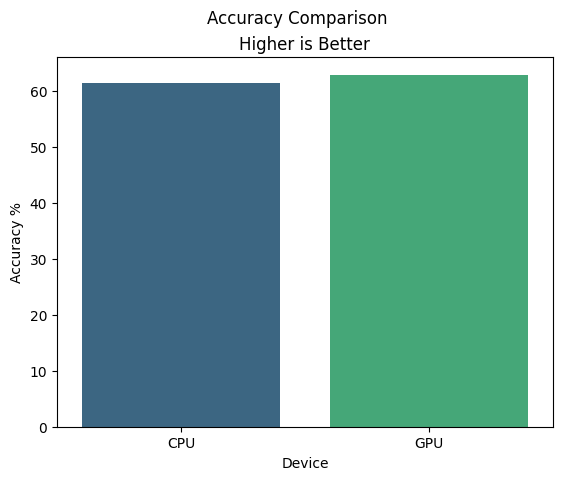

In [17]:
# Creating a bar plot to compare the training times
sns.barplot(x=['CPU', 'GPU'], y=[accuracy_cpu, accuracy_gpu], palette='viridis')
plt.suptitle('Accuracy Comparison')
plt.title('Higher is Better')
plt.xlabel('Device')
plt.ylabel('Accuracy %')

plt.show()

### here both cpu and gpu have the nearly the same accuracy because we are using the same model architecture and training data, and the only difference is the device on which the computations are performed.

#### **The small difference in the plot is due to the fact that we are using random seed for both runs**


In [18]:
# similar to before we are calculating the accuracy for each class
# in the CIFAR-10 dataset using the model trained on the GPU.
correct_predict = {classname: 0 for classname in classes}
total_predict = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = net_gpu(inputs)
        _, predicted = torch.max(outputs, 1)
        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_predict[classes[label]] += 1
            total_predict[classes[label]] += 1

accuracy_per_class_gpu = {}
for classname, correct_count in correct_predict.items():
    accuracy = 100 * correct_count / total_predict[classname]
    accuracy_per_class_gpu[classname] = accuracy
    print(f'Accuracy for class {classname:5s} is {accuracy:.1f} %')

Accuracy for class plane is 69.2 %
Accuracy for class car   is 74.3 %
Accuracy for class bird  is 37.3 %
Accuracy for class cat   is 45.6 %
Accuracy for class deer  is 51.3 %
Accuracy for class dog   is 53.2 %
Accuracy for class frog  is 72.6 %
Accuracy for class horse is 71.1 %
Accuracy for class ship  is 79.9 %
Accuracy for class truck is 74.3 %


In [19]:
import pandas as pd
accuracy_per_class = pd.DataFrame({
    'CPU': accuracy_per_class_cpu,
    'GPU': accuracy_per_class_gpu
})

accuracy_per_class.reset_index(inplace=True)
accuracy_per_class.rename(columns={'index': 'category'}, inplace=True)

accuracy_per_class


,category,CPU,GPU
0,plane,71.3,69.2
1,car,77.5,74.3
2,bird,52.1,37.3
3,cat,56.1,45.6
4,deer,52.7,51.3
5,dog,35.8,53.2
6,frog,66.8,72.6
7,horse,70.9,71.1
8,ship,65.9,79.9
9,truck,65.5,74.3


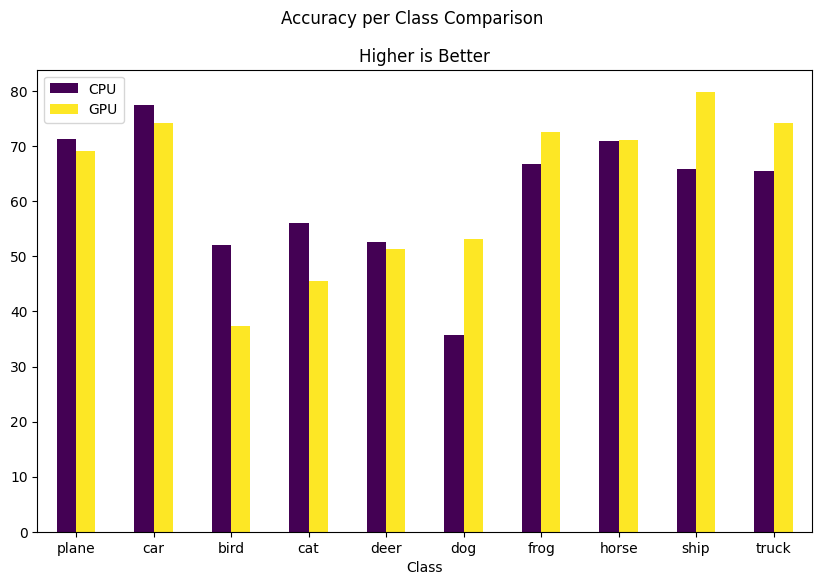

In [20]:
# creating a grouped bar plot to compare the accuracy for each class between the CPU and GPU trained models
accuracy_per_class.plot(x='category', y=['CPU', 'GPU'], kind='bar', figsize=(10, 6), colormap='viridis')
plt.suptitle('Accuracy per Class Comparison')
plt.xticks(rotation=0)
plt.title('Higher is Better')
plt.xlabel('Class')
plt.show()

### here the accuracy difference between the CPU and GPU trained models for each class is different across classes, with some classes showing a larger improvement in accuracy when using the GPU-trained model compared to the CPU-trained model. and the other way around some classes show a larger improvement in accuracy when using the CPU-trained model compared to the GPU-trained model.

### this is due random seed and the fact that the training process is not deterministic, which can lead to variations in the model's performance across different runs.